# Plot results

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

In [42]:
def plot_multiple_max_latency(input_files, output_image="./plot_comparison_max.png"):
    try:
        plt.figure(figsize=(12, 6))
        
        # Define a list of distinct colors for the maximum latency lines
        colors = ['red', 'darkorange', 'purple', 'green', 'dodgerblue', 'brown']
        
        for i, input_file in enumerate(input_files):
            # Use the filename (without extension) as the label
            base_name = os.path.basename(input_file)
            label_name = os.path.splitext(base_name)[0]
            
            # Dynamic file format handling
            if input_file.endswith('.csv'):
                data = np.loadtxt(input_file, delimiter=',', skiprows=1)
            else:
                data = np.loadtxt(input_file)
                
            if data.size == 0:
                print(f"Warning: {input_file} contains no valid data, skipping.")
                continue

            cycles = data[:, 0]
            latencies = data[:, 1]
            
            # Calculate the Cumulative Maximum (WCET Envelope)
            cumulative_max = np.maximum.accumulate(latencies)
            absolute_max = cumulative_max[-1]
            
            color = colors[i % len(colors)]
            
            # Plot ONLY the cumulative maximum line (no scatter points)
            plt.plot(cycles, cumulative_max, color=color, linewidth=2.0, 
                     label=f"{label_name} (Max: {int(absolute_max)} µs)")

        # Formatting
        # plt.title('Worst-Case Execution Time (WCET) Envelope Comparison', fontsize=12, fontweight='bold')
        plt.xlabel('Cycle Count', fontsize=10)
        plt.ylabel('Max Latency (microseconds)', fontsize=10)
        
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend(loc='upper left', framealpha=0.9)
        
        plt.tight_layout()
        plt.savefig(output_image, dpi=300)
        print(f"Comparison max-latency plot successfully saved as {output_image}")
        plt.show()

    except Exception as e:
        print(f"Error generating the comparison plot: {e}")

In [43]:
def plot_ecdf(input_files, output_image="./cdf_comparison.png"):
    try:
        plt.figure(figsize=(10, 8))
        
        # Line styles and markers to mimic publication-grade charts
        styles = [
            {'color': 'green', 'marker': 's', 'markevery': 5000},  # Square
            {'color': 'blue', 'marker': '^', 'markevery': 5000},   # Triangle up
            {'color': 'darkorange', 'marker': 'v', 'markevery': 5000}, # Triangle down
            {'color': 'red', 'marker': 'o', 'markevery': 5000}     # Circle
        ]
        
        for i, input_file in enumerate(input_files):
            base_name = os.path.basename(input_file)
            label_name = os.path.splitext(base_name)[0]
            
            # Dynamic file format handling
            if input_file.endswith('.csv'):
                data = np.loadtxt(input_file, delimiter=',', skiprows=1)
            else:
                data = np.loadtxt(input_file)
                
            if data.size == 0:
                print(f"Warning: {input_file} contains no valid data, skipping.")
                continue

            latencies = data[:, 1]
            
            # 1. Sort the latencies for CDF calculation
            sorted_latencies = np.sort(latencies)
            
            # 2. Compute cumulative probabilities (from 1/N to 1.0)
            p = np.arange(1, len(sorted_latencies) + 1) / len(sorted_latencies)
            
            style = styles[i % len(styles)]
            
            # Plot using step function ('post' is standard for empirical CDFs)
            plt.step(sorted_latencies, p, where='post', 
                     color=style['color'], 
                     linewidth=1.5,
                     label=label_name)
            
            # Add markers sparsely along the step line for visual identification
            plt.plot(sorted_latencies[::style['markevery']], p[::style['markevery']], 
                     marker=style['marker'], 
                     color=style['color'], 
                     linestyle='None', 
                     markersize=6, 
                     markerfacecolor='none')

        # Formatting to mirror academic style
        # Formatting to mirror academic style (using raw strings 'r""' for LaTeX symbols)
        plt.title(r'Experimental CDF of Cyclictest Latencies', fontsize=12, fontweight='bold')
        plt.xlabel(r'L ($\mu$s)', fontsize=11)
        plt.ylabel(r'P(latency $\leq$ L)', fontsize=11)
        
        plt.xscale("log")
        
        plt.xlim(left=0)
        plt.ylim(0, 1.02)
        
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(loc='lower right', framealpha=0.9)
        
        plt.tight_layout()
        plt.savefig(output_image, dpi=300)
        print(f"CDF comparison plot successfully saved as {output_image}")
        plt.show()

    except Exception as e:
        print(f"Error generating the CDF plot: {e}")

Comparison max-latency plot successfully saved as ./plot_comparison_max.png


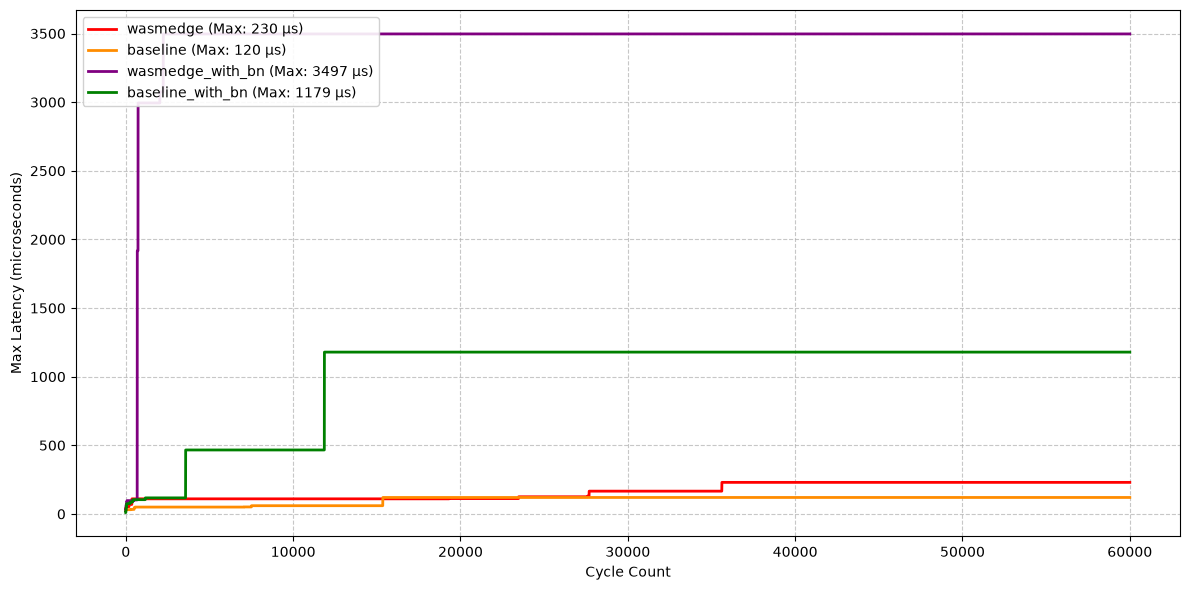

In [44]:
file_name = ["wasmedge", "baseline", "wasmedge_with_bn", "baseline_with_bn"]

plot_multiple_max_latency([f"./results/{name}.csv" for name in file_name])

/tmp/ipykernel_1522072/2196257446.py:59: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(left=0)


CDF comparison plot successfully saved as ./cdf_comparison.png


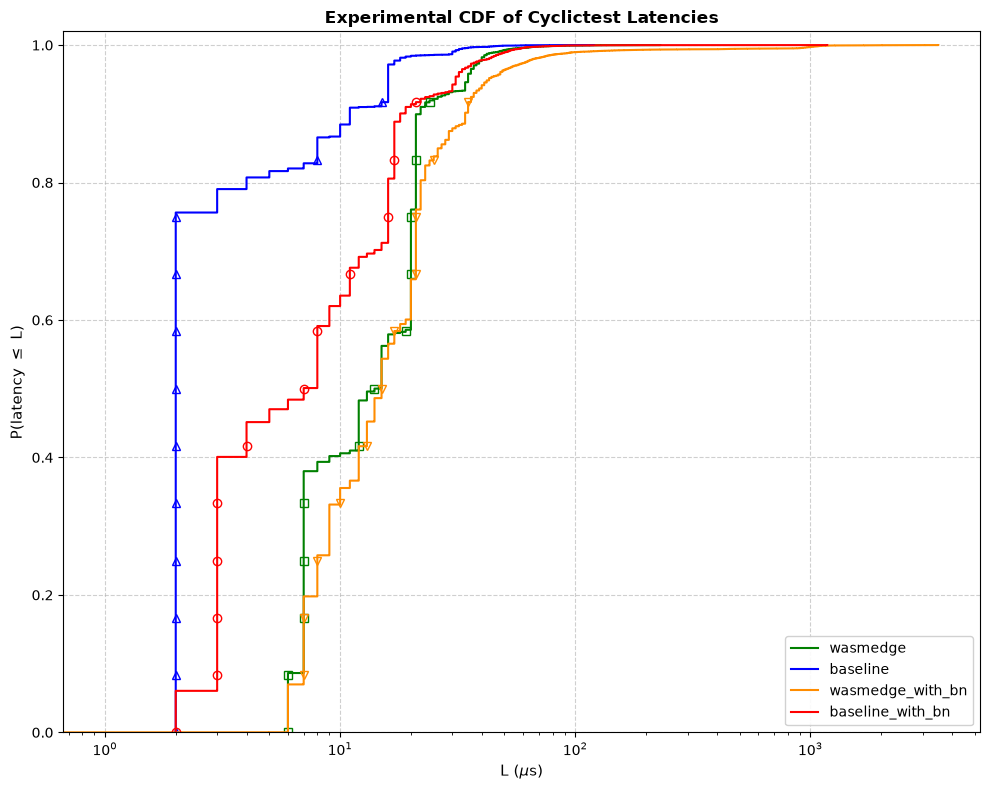

In [45]:
file_name = ["wasmedge", "baseline", "wasmedge_with_bn", "baseline_with_bn"]

plot_ecdf([f"./results/{name}.csv" for name in file_name])